# Expense Remarks Classification
**Assignment:** AI/ML/NLP Candidate Test  
**Task:** Predict expense type — Services, Equipment, or Material — from free-text remarks  
**Chosen Approach:** Sentence Transformers (`all-mpnet-base-v2`) + LinearSVC  
**Evaluation Metrics:** Macro F1-Score and Accuracy

---
## 1. Install and Import Libraries

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn openpyxl sentence-transformers -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sentence_transformers import SentenceTransformer

import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully!')

d:\backup\Assigment_Project\APTINO\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully!



## 2. Load Data

In [3]:
df = pd.read_excel('data.xlsx')
print('Shape:', df.shape)
df.head(10)

Shape: (268, 6)


,Year,Debit,Credit,Net,Remarks,Label
0,FY23,30000.0,0,30000.0,"Services Professional Services , Consultancy A...",Services
1,FY23,270000.0,0,270000.0,"Services Professional Services , Consultancy A...",Services
2,FY23,250000.0,0,250000.0,Exp reclass entry in N2 (Godrej),Services
3,FY23,14500.0,0,14500.0,Dispenser Water - Frosty plus - (Make - Atlantis),Equipment
4,FY23,59400.0,0,59400.0,"Almirah - Office use , Steel Almirah with four...",Equipment
5,FY23,59400.0,0,59400.0,"701257471208 Almirah - Office use , Steel Almi...",Equipment
6,FY23,12400.0,0,12400.0,Dispenser Water - Frosty plus - (Make - Atlantis),Equipment
7,FY23,12735479.0,0,12735479.0,Space matrix Cost T/f from project Upgradation...,Services
8,FY23,315000.0,0,315000.0,Provision reclass of Godrej May22,Services
9,FY23,30200.0,0,30200.0,1.5 Tr. Split AC - 2 Star - Non Inverter ( Dai...,Equipment


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 268 entries, 0 to 267
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Year     268 non-null    str    
 1   Debit    268 non-null    float64
 2   Credit   268 non-null    int64  
 3   Net      268 non-null    float64
 4   Remarks  267 non-null    str    
 5   Label    268 non-null    str    
dtypes: float64(2), int64(1), str(3)
memory usage: 12.7 KB



## 3. Data Cleaning



In [5]:
# Check before cleaning
print('Missing values:')
print(df.isna().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')

Missing values:
Year       0
Debit      0
Credit     0
Net        0
Remarks    1
Label      0
dtype: int64

Duplicate rows: 31


In [6]:
# Remove missing and duplicate rows
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

print(f'Rows remaining after cleaning: {len(df)}')

Rows remaining after cleaning: 236


In [7]:
# Text cleaning function
def clean_text(text):
    text = str(text).lower()             # lowercase
    text = re.sub(r'\d+', '', text)      # remove numbers
    text = re.sub(r'[^\w\s]', '', text)  # remove punctuation
    return text.strip()

df['Clean_remarks'] = df['Remarks'].apply(clean_text)

# Show before vs after
df[['Remarks', 'Clean_remarks']].head(5)

,Remarks,Clean_remarks
0,"Services Professional Services , Consultancy A...",services professional services consultancy ar...
1,"Services Professional Services , Consultancy A...",services professional services consultancy ar...
2,Exp reclass entry in N2 (Godrej),exp reclass entry in n godrej
3,Dispenser Water - Frosty plus - (Make - Atlantis),dispenser water frosty plus make atlantis
4,"Almirah - Office use , Steel Almirah with four...",almirah office use steel almirah with four s...



## 4. Exploratory Data Analysis (EDA)

### 4.1 Label Distribution


In [8]:
label_counts = df['Label'].value_counts()
print('Label counts:')
print(label_counts)
print(f'\nTotal: {len(df)} samples')


Label counts:
Label
Equipment    124
Services      76
Material      36
Name: count, dtype: int64

Total: 236 samples


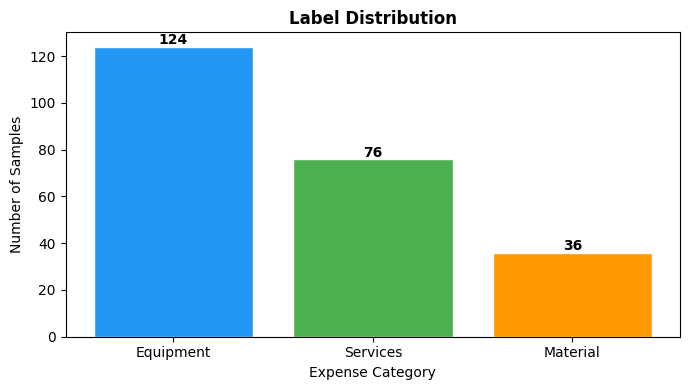

In [9]:
# Bar chart — number of samples per category
colors = ['#2196F3', '#4CAF50', '#FF9800']

plt.figure(figsize=(7, 4))
bars = plt.bar(label_counts.index, label_counts.values, color=colors, edgecolor='white')
for bar, v in zip(bars, label_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, v + 1, str(v),
             ha='center', fontweight='bold')
plt.title('Label Distribution', fontweight='bold')
plt.ylabel('Number of Samples')
plt.xlabel('Expense Category')
plt.tight_layout()
plt.show()

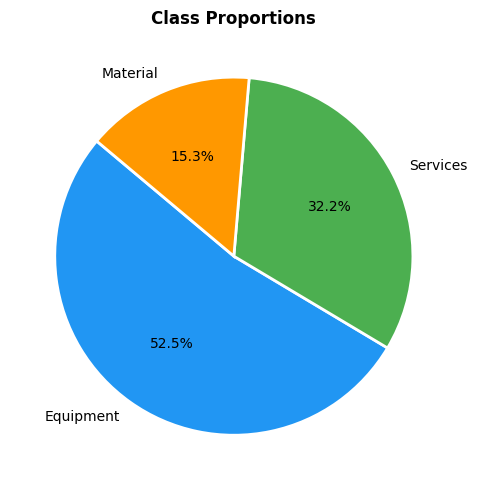

In [10]:
# Pie chart — class proportions
plt.figure(figsize=(6, 5))
plt.pie(label_counts.values, labels=label_counts.index,
        autopct='%1.1f%%', colors=colors, startangle=140,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title('Class Proportions', fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2 Text Length Analysis


In [11]:
df['text_length'] = df['Clean_remarks'].apply(len)

print('Average remark length by category:')
print(df.groupby('Label')['text_length'].mean().round(1))

Average remark length by category:
Label
Equipment    51.2
Material     57.6
Services     62.1
Name: text_length, dtype: float64


<Figure size 700x400 with 0 Axes>

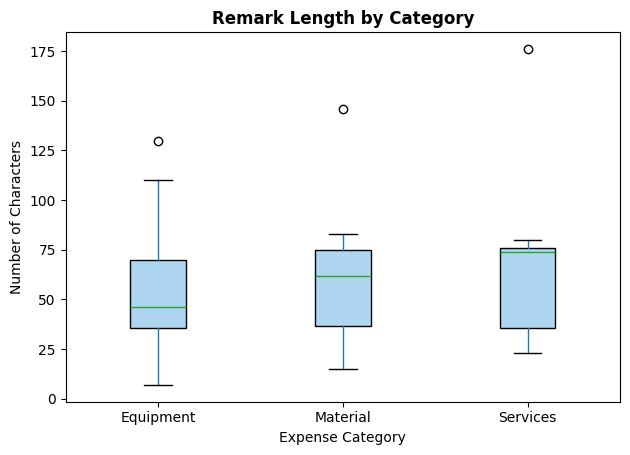

In [12]:
# Boxplot — text length spread per category
plt.figure(figsize=(7, 4))
df.boxplot(column='text_length', by='Label',
           patch_artist=True, grid=False,
           boxprops=dict(facecolor='#AED6F1'))
plt.title('Remark Length by Category', fontweight='bold')
plt.suptitle('')
plt.xlabel('Expense Category')
plt.ylabel('Number of Characters')
plt.tight_layout()
plt.show()

### 4.3 Debit Amount Analysis


In [13]:
print('Debit amount statistics by category:')
print(df.groupby('Label')['Debit'].describe().round(2))

Debit amount statistics by category:
           count        mean         std     min       25%       50%  \
Label                                                                  
Equipment  124.0    58265.04    98506.58   300.0  10482.50  29941.25   
Material    36.0    13985.32    18785.64   540.4   1595.00   5775.00   
Services    76.0  1057606.60  2842289.17  1260.0  13420.42  78500.00   

                 75%         max  
Label                             
Equipment   67050.00    882000.0  
Material    18868.75     76000.0  
Services   250000.00  12735479.0  


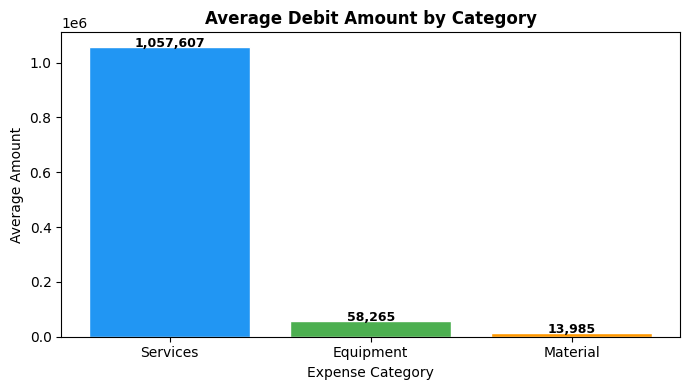

In [14]:
# Average debit amount per category
avg_debit = df.groupby('Label')['Debit'].mean().sort_values(ascending=False)

plt.figure(figsize=(7, 4))
bars = plt.bar(avg_debit.index, avg_debit.values, color=colors, edgecolor='white')
for bar, v in zip(bars, avg_debit.values):
    plt.text(bar.get_x() + bar.get_width() / 2, v + 500,
             f'{v:,.0f}', ha='center', fontsize=9, fontweight='bold')
plt.title('Average Debit Amount by Category', fontweight='bold')
plt.ylabel('Average Amount')
plt.xlabel('Expense Category')
plt.tight_layout()
plt.show()


## 5. Train / Test Split


In [15]:
X = df['Clean_remarks']
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'Training samples : {len(X_train)}')
print(f'Testing samples  : {len(X_test)}')

Training samples : 188
Testing samples  : 48



## 6. Build Model — Sentence Transformers + LinearSVC


In [16]:
# Load pre-trained model 
embedder = SentenceTransformer('all-mpnet-base-v2')

print('Generating sentence embeddings...')
X_train_emb = embedder.encode(X_train.tolist(), show_progress_bar=True)
X_test_emb  = embedder.encode(X_test.tolist(),  show_progress_bar=True)

print(f'\nEmbedding shape: {X_train_emb.shape}')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 477.82it/s, Materializing param=pooler.dense.weight]                        
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Generating sentence embeddings...


Batches: 100%|██████████| 2/2 [00:02<00:00,  1.03s/it]


Embedding shape: (188, 768)


In [17]:
# Train classifier on the embeddings
model = LinearSVC(class_weight='balanced', max_iter=2000, random_state=42)
model.fit(X_train_emb, y_train)

print('Model trained successfully!')

Model trained successfully!


### Save Model


In [18]:
import joblib

# Save the trained classifier
joblib.dump(model, 'expense_classifier.pkl')

print('Model saved as expense_classifier.pkl')

Model saved as expense_classifier.pkl



## 7. Evaluate Model



In [19]:
y_pred = model.predict(X_test_emb)

print('Classification Report')
print('=' * 50)
print(classification_report(y_test, y_pred))

Classification Report
              precision    recall  f1-score   support

   Equipment       0.95      0.84      0.89        25
    Material       0.88      1.00      0.93         7
    Services       0.83      0.94      0.88        16

    accuracy                           0.90        48
   macro avg       0.89      0.93      0.90        48
weighted avg       0.90      0.90      0.90        48



In [20]:
# 5-Fold Cross-Validation for reliable performance estimate
X_all_emb = embedder.encode(X.tolist(), show_progress_bar=False)

cv_f1  = cross_val_score(model, X_all_emb, y, cv=cv, scoring='f1_macro')
cv_acc = cross_val_score(model, X_all_emb, y, cv=cv, scoring='accuracy')

print(f'5-Fold CV Macro F1 : {cv_f1.mean():.4f}  ±  {cv_f1.std():.4f}')
print(f'5-Fold CV Accuracy : {cv_acc.mean():.4f}  ±  {cv_acc.std():.4f}')

5-Fold CV Macro F1 : 0.8885  ±  0.0264
5-Fold CV Accuracy : 0.9067  ±  0.0218


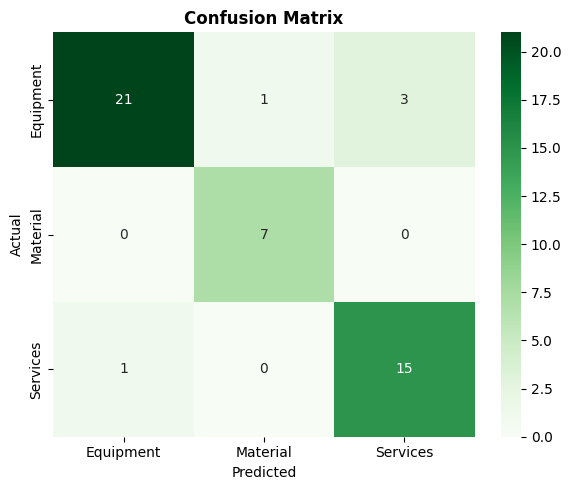

In [21]:
# Confusion Matrix
labels = ['Equipment', 'Material', 'Services']
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [22]:
# How to reload and use the model next time — no retraining needed
#
# from sentence_transformers import SentenceTransformer
# import joblib
#
# embedder = SentenceTransformer('all-mpnet-base-v2')  # loads from cache
# model    = joblib.load('expense_classifier.pkl')      # loads saved classifier
#
# new_remarks = ['Supply of SFP module', 'Installation and commissioning']
# embeddings  = embedder.encode(new_remarks)
# predictions = model.predict(embeddings)
# print(predictions)  # e.g. ['Material', 'Services']

